In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import matplotlib.pyplot as plt
from matplotlib import colors

import sys
sys.path.append("../src")

import netket as nk

from netket.experimental.dynamics import RK45

from callbacks import (
    get_tdvp_monitor_callback,
    get_umbrella_monitor_callback,
)

from logger import Logger

/mnt/home/rwiersema/blurred_sampling/.venv_plot/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: To build H|ψ⟩ use nk.vqs.apply_operator(H, vstate_ψ).

In [3]:
import jax.numpy as jnp
import numpy as np
import flax.linen as nn

N = 4
hilbert = nk.hilbert.Spin(s=1 / 2, N=N)

def get_vstate(n_samples):
    model = nk.models.RBM(param_dtype=complex, alpha=1)
    sampler = nk.sampler.MetropolisLocal(hilbert, n_chains=n_samples)
    model = nk.models.RBM(
        alpha=1,
        param_dtype=complex,
        use_visible_bias=True,
        hidden_bias_init=nn.initializers.normal(1e-4),
        visible_bias_init=nn.initializers.normal(1e-4),
        kernel_init=nn.initializers.normal(1e-4),
    )
    vstate = nk.vqs.MCState(
        sampler=sampler, model=model, n_samples=n_samples, seed=100, sampler_seed=100
    )
    eps_params = vstate.parameters.copy()
    K = 3
    a = jnp.array([-K]*N, dtype=eps_params['visible_bias'].dtype)
    eps_params["visible_bias"] = a
    vstate.parameters = eps_params.copy()
    
    # Thermalize
    for i in range(100):
        vstate.sample(n_samples=n_samples)
    return vstate


vstate = get_vstate(2**9)
print("Single peak state")
print(vstate.to_array())

Single peak state
[3.77508849e-11-1.72986633e-18j 1.52297925e-08-2.34200470e-16j
 1.52297925e-08-5.61554597e-16j 6.14413676e-06-7.59116770e-15j
 1.52297928e-08+2.17640347e-16j 6.14413679e-06-1.16286597e-13j
 6.14413671e-06+1.05012292e-13j 2.47872182e-03-2.71028976e-11j
 1.52297943e-08-2.80581517e-16j 6.14413654e-06+2.40335140e-13j
 6.14413702e-06-2.12048283e-13j 2.47872158e-03+6.99452117e-11j
 6.14413707e-06+7.06054276e-14j 2.47872158e-03+1.33072784e-11j
 2.47872173e-03-2.66404213e-11j 9.99987712e-01-1.16792283e-08j]


In [4]:
graph = nk.graph.Chain(N, pbc=True)
hamiltonian = nk.operator.IsingJax(hilbert=hilbert, graph=graph, h=1., J=-1.)
n_samples_list = [2**i for i in range(9,15)]

for i in range(N):
    string = ["I"]*N
    string[i] = "Z"
    if i==0:
        sigma_zs=nk.operator.PauliStringsJax(hilbert, "".join(string), 1./N)
    else:
        sigma_zs+=nk.operator.PauliStringsJax(hilbert, "".join(string), 1./N)
fields_to_track = (
    ("t", "values"),
    ("dt", "values"),
    ("Generator", "Mean"),
    ("Generator", "Variance"),
    ("sigma_z", "Mean"),
    ("sigma_z", "Variance"),
    ("r_squared", "values"),
    # Umbrella/bridge monitoring fields
    ("ess_bridge", "values"),
    ("snr_min", "values"),
    ("snr_10p", "values"),
    ("snr_med", "values"),
    ("snrF_min", "values"),
    ("snrF_med", "values"),
    ("q_bridge", "values"),
    # Per-step SNRs from OVar
    ("snr", "values"),
    ("snr_F", "values"),
)


def measure_sigma_z(step, log, driver):
    log['sigma_z'] = driver.state.expect(sigma_zs)
    return True

# Exact dynamics

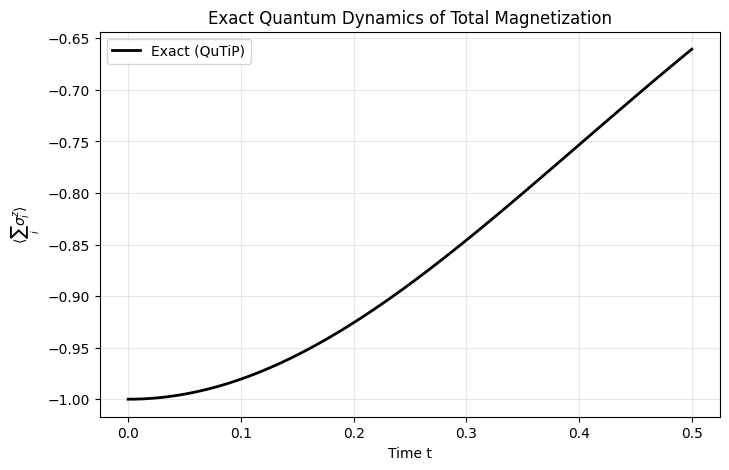

Initial magnetization: -0.999988
Final magnetization: -0.660618


In [5]:
import qutip as qt

# Get the Hamiltonian matrix from netket
H_matrix = hamiltonian.to_sparse()

# Convert to QuTiP Qobj
H_qutip = qt.Qobj(H_matrix)

# Get initial state from vstate
psi0_array = vstate.to_array()
psi0_qutip = qt.Qobj(psi0_array)
psi0_qutip = psi0_qutip.unit()  # Normalize

# Create total magnetization operator (sum of Z_i)
# Convert netket operator to matrix
sigma_z_matrix = sigma_zs.to_sparse() * N  # Multiply by N since sigma_zs is normalized by 1/N

# Convert to QuTiP
Z_total_qutip = qt.Qobj(sigma_z_matrix)

# Time evolution parameters
T = 0.5
times_exact = np.linspace(0.0, T, 100)

# Evolve the state and calculate expectation values
magnetizations_exact = []
for t in times_exact:
    # Evolve state
    psi_t = (-1j * H_qutip * t).expm() * psi0_qutip
    # Calculate expectation value
    mag = qt.expect(Z_total_qutip, psi_t)
    magnetizations_exact.append(mag / 4)

# Plot the exact dynamics
plt.figure(figsize=(8, 5))
plt.plot(times_exact, np.real(magnetizations_exact), 'k-', linewidth=2, label='Exact (QuTiP)')
plt.xlabel('Time t')
plt.ylabel(r'$\langle \sum_i \sigma^z_i \rangle$')
plt.title('Exact Quantum Dynamics of Total Magnetization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Initial magnetization: {np.real(magnetizations_exact[0]):.6f}")
print(f"Final magnetization: {np.real(magnetizations_exact[-1]):.6f}")

## Dynamics

In [ ]:
from schmitt_tdvp import TDVPSchmitt
from schmitt_tdvp_randomized_bridge import TDVPSchmittRandomizedBridge

def fit(flip_prob, n_samples_tvmc):    
    T = 0.5
    save_times = np.linspace(0.0, T, 20)
    exp_name = f"{n_samples_tvmc}_{flip_prob:1.2f}"
    # Make sure we always start with the same state in notebook
    
    save_path = f"./data/TFIM_EPS_{N}/{exp_name}/"
    logger = Logger(path=save_path, fields=fields_to_track)
    if logger.restore():
        if logger.done:
            print("Data exists, skipping...")
            return
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    
    vstate = get_vstate(n_samples_tvmc)
    print(vstate.expect(sigma_zs))
    callbacks = []
    callbacks.append(measure_sigma_z)
    tdvp_monitor_callback = get_tdvp_monitor_callback(save_times, save_path)
    callbacks.append(tdvp_monitor_callback)
    integrator = RK45(1e-3)
    tvmc_kwargs = {}
    if flip_prob==0:
        driver = TDVPSchmitt(
            hamiltonian,
            vstate,
            integrator,
            t0=0,
            holomorphic=False,
            snr_atol=2,
            rcond=1e-14,
            rcond_smooth=1e-10,
            **tvmc_kwargs,
        )
    else:
        driver = TDVPSchmittRandomizedBridge(
        hamiltonian,
        vstate,
        integrator,
        t0=0,
        flip_prob=flip_prob,
        holomorphic=False,
        snr_atol=2,
        rcond=1e-14,
        rcond_smooth=1e-10,
            **tvmc_kwargs,
        )
    driver.run(
        T,
        out=logger,
        callback = callbacks,
        show_progress=True,
        timeit=True,
    )
    logger.flush(vstate, done=True)

In [ ]:
for n_samples_tvmc in n_samples_list:
    fit(0.0, n_samples_tvmc)
    fit(0.1, n_samples_tvmc)


File not found
-1.00e+00+0.00e+00j ± nan [σ²=0.0e+00]


100%|██████████| 0.50/0.50 [00:33<00:00, 67.1s/it, n=500, Generator=-4.00953094699852474747-0.02903610345941703627j ± 0.00000000000000000015 e+00 [σ²=1.2e-35]]                       


╭────────────────────────────────────────────── Timing Information ───────────────────────────────────────────────╮
│ Total: 33.556                                                                                                   │
│ ├── (1.3%) | MCState.expect : 0.448 s                                                                           │
│ ├── (27.0%) | MCState.local_estimators : 9.052 s                                                                │
│ │   └── (63.3%) | MCState.sample : 5.727 s                                                                      │
│ │       └── (60.5%) | sampling n_discarded samples : 3.465 s                                                    │
│ ├── (5.3%) | QGTJacobian_DefaultConstructor : 1.782 s                                                           │
│ │   └── (49.7%) | jacobian : 0.885 s                                                                            │
│ └── (17.8%) | _impl : 5.965 s                                         

100%|██████████| 0.50/0.50 [00:28<00:00, 57.2s/it, n=500, Generator=-4.146-0.091j ± 0.087 [σ²=3.9e+00]]


╭────────────────────────────────────────────── Timing Information ───────────────────────────────────────────────╮
│ Total: 28.610                                                                                                   │
│ ├── (1.4%) | MCState.expect : 0.390 s                                                                           │
│ ├── (18.0%) | MCState.sample : 5.158 s                                                                          │
│ │   └── (65.4%) | sampling n_discarded samples : 3.371 s                                                        │
│ ├── (6.2%) | QGTJacobian_DefaultConstructor : 1.761 s                                                           │
│ │   └── (42.1%) | jacobian : 0.742 s                                                                            │
│ └── (18.8%) | _impl : 5.379 s                                                                                   │
╰───────────────────────────────────────────────────────────────────────

...

╭────────────────────────────────────────────── Timing Information ───────────────────────────────────────────────╮
│ Total: 53.483                                                                                                   │
│ ├── (1.1%) | MCState.expect : 0.598 s                                                                           │
│ ├── (36.8%) | MCState.sample : 19.705 s                                                                         │
│ │   └── (77.0%) | sampling n_discarded samples : 15.168 s                                                       │
│ ├── (8.0%) | QGTJacobian_DefaultConstructor : 4.276 s                                                           │
│ │   └── (70.6%) | jacobian : 3.017 s                                                                            │
│ └── (13.3%) | _impl : 7.120 s                                                                                   │
╰───────────────────────────────────────────────────────────────────────

100%|██████████| 0.50/0.50 [01:24<00:00, 168s/it, n=500, Generator=-4.025-0.007j ± 0.015 [σ²=3.9e+00]]                                                             


╭────────────────────────────────────────────── Timing Information ───────────────────────────────────────────────╮
│ Total: 84.305                                                                                                   │
│ ├── (57.1%) | MCState.local_estimators : 48.157 s                                                               │
│ │   └── (73.4%) | MCState.sample : 35.346 s                                                                     │
│ │       └── (76.8%) | sampling n_discarded samples : 27.130 s                                                   │
│ ├── (4.1%) | QGTJacobian_DefaultConstructor : 3.447 s                                                           │
│ │   └── (60.5%) | jacobian : 2.087 s                                                                            │
│ └── (13.6%) | _impl : 11.488 s                                                                                  │
╰───────────────────────────────────────────────────────────────────────

100%|██████████| 0.50/0.50 [01:21<00:00, 164s/it, n=500, Generator=-4.016-0.005j ± 0.016 [σ²=4.3e+00]]   


╭────────────────────────────────────────────── Timing Information ───────────────────────────────────────────────╮
│ Total: 82.004                                                                                                   │
│ ├── (43.2%) | MCState.sample : 35.409 s                                                                         │
│ │   └── (77.0%) | sampling n_discarded samples : 27.267 s                                                       │
│ ├── (9.5%) | QGTJacobian_DefaultConstructor : 7.759 s                                                           │
│ │   └── (78.9%) | jacobian : 6.119 s                                                                            │
│ └── (12.0%) | _impl : 9.835 s                                                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯



Restored Vanilla: True
Restored Blur: True
Restored Vanilla: True
Restored Blur: True
Restored Vanilla: True
Restored Blur: True
Restored Vanilla: True
Restored Blur: True
Restored Vanilla: True
Restored Blur: True
Restored Vanilla: True
Restored Blur: True


/mnt/home/rwiersema/blurred_sampling/.venv_plot/lib/python3.11/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/home/rwiersema/blurred_sampling/.venv_plot/lib/python3.11/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


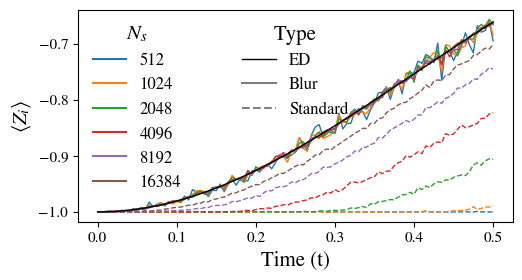

In [6]:
import matplotlib
matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"
import matplotlib.lines as mlines
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(5.8, 5.5/2))
gs = GridSpec(1, 1, figure=fig, wspace=0.45, hspace=0.33)
ax_z = fig.add_subplot(gs[0])
fig.subplots_adjust(left=0.15)

color_map = plt.get_cmap('tab10')
ns_handles = []
for idx, n_samples in enumerate(n_samples_list):
    color = color_map(idx % 10)
    # Vanilla (flip_prob=0.0)
    exp_name_vanilla = f"{n_samples}_0.00"
    save_path_vanilla = f"./data/TFIM_EPS_{N}/{exp_name_vanilla}/"
    logger_vanilla = Logger(path=save_path_vanilla, fields=fields_to_track)
    print("Restored Vanilla:", logger_vanilla.restore())
    ax_z.plot(logger_vanilla.data["t"]["values"][::5], logger_vanilla.data["sigma_z"]["Mean"][::5], color=color, linestyle='--', lw=1)
    # Blur (flip_prob=0.1)
    exp_name_blur = f"{n_samples}_0.10"
    save_path_blur = f"./data/TFIM_EPS_{N}/{exp_name_blur}/"
    logger_blur = Logger(path=save_path_blur, fields=fields_to_track)
    print("Restored Blur:", logger_blur.restore())
    ax_z.plot(logger_blur.data["t"]["values"][::5], logger_blur.data["sigma_z"]["Mean"][::5], color=color, linestyle='-',lw=1)
    ns_handles.append(mlines.Line2D([], [], color=color, linestyle='-', label=f'{n_samples}'))
ax_z.set_xlabel("Time (t)", fontsize=15)
ax_z.set_ylabel(r"$\langle Z_i \rangle$", fontsize=15)
ed_handle = mlines.Line2D([], [], color='k', linestyle='-', linewidth=1, label='ED')
vanilla_handle = mlines.Line2D([], [], color='gray', linestyle='-', label='Blur')
blur_handle = mlines.Line2D([], [], color='gray', linestyle='--', label='Standard')
ax_z.plot(times_exact, np.real(magnetizations_exact), 'k-', linewidth=1)
# Place the ED, Vanilla, Blur legend
first_legend = ax_z.legend(handles=[ed_handle, vanilla_handle, blur_handle], loc='upper center', fontsize=12, frameon=False, title='Type', title_fontsize=15)
ax_z.add_artist(first_legend)
ax_z.tick_params(labelsize=11)
loc_x = -0.18
loc_y = 0.95
# ax_z.annotate("(b)", xy=(loc_x, loc_y), xycoords="axes fraction", fontsize=16)
# Place the Ns legend separately
ax_z.legend(handles=ns_handles, loc='upper left', fontsize=12, frameon=False, title='$N_s$', title_fontsize=15)
fig.savefig("Fig6.pdf",bbox_inches="tight", pad_inches=0.01)